# 03 Bertscore Semantic Evaluation

**Project:** LLMOps Monitoring & Evaluation Platform

**Notebook:** `03-bertscore-semantic-evaluation.ipynb`

In [5]:
# !pip install bert-score

In [6]:
# Start coding here
# ==========================================
# Notebook 03
# BERTScore Semantic Evaluation
# ==========================================

import pandas as pd

from bert_score import score

In [7]:
df = pd.read_csv("../data/golden_dataset.csv")

df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN


In [8]:
reference = "AWS is Amazon Web Services, a cloud computing platform."

prediction = "AWS is Amazon's cloud platform."

In [9]:
P, R, F1 = score([prediction], [reference], lang="en", verbose=False)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vinna\.cache\huggingface\hub\models--roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
print("Precision:", P.item())

print("Recall:", R.item())

print("F1:", F1.item())

Precision: 0.9463489055633545
Recall: 0.9117016792297363
F1: 0.9287022948265076


In [11]:
def compute_bertscore(prediction, reference):

    P, R, F1 = score([prediction], [reference], lang="en", verbose=False)

    return {
        "bertscore_precision": float(P.item()),
        "bertscore_recall": float(R.item()),
        "bertscore_f1": float(F1.item()),
    }

In [12]:
compute_bertscore(prediction, reference)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'bertscore_precision': 0.9463489055633545,
 'bertscore_recall': 0.9117016792297363,
 'bertscore_f1': 0.9287022948265076}

In [13]:
reference = "The application works perfectly"

prediction = "The software functions brilliantly"

In [14]:
compute_bertscore(prediction, reference)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'bertscore_precision': 0.9558544754981995,
 'bertscore_recall': 0.9558544754981995,
 'bertscore_f1': 0.9558544754981995}

In [15]:
results = []

In [16]:
for _, row in df.iterrows():

    scores = compute_bertscore(row["generated_response"], row["ground_truth"])

    results.append(scores)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You sho

In [17]:
bertscore_df = pd.DataFrame(results)

bertscore_df.head()

,bertscore_precision,bertscore_recall,bertscore_f1
0,0.946349,0.911702,0.928702
1,0.930594,0.903113,0.916648
2,0.974678,0.939706,0.956872
3,0.940704,0.921139,0.930819
4,0.939632,0.920771,0.930106


In [18]:
evaluation_df = pd.concat([df, bertscore_df], axis=1)

In [19]:
evaluation_df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length,bertscore_precision,bertscore_recall,bertscore_f1
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0,0.946349,0.911702,0.928702
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0,0.930594,0.903113,0.916648
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0,0.974678,0.939706,0.956872
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN,0.940704,0.921139,0.930819
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN,0.939632,0.920771,0.930106


In [20]:
evaluation_df[["bertscore_precision", "bertscore_recall", "bertscore_f1"]].mean()

bertscore_precision    0.888383
bertscore_recall       0.884716
bertscore_f1           0.886463
dtype: float64

In [21]:
def semantic_quality(score):

    if score >= 0.90:
        return "Excellent"

    elif score >= 0.80:
        return "Good"

    elif score >= 0.70:
        return "Average"

    return "Poor"

In [22]:
evaluation_df["semantic_quality"] = evaluation_df["bertscore_f1"].apply(
    semantic_quality
)

In [23]:
evaluation_df[["question", "bertscore_f1", "semantic_quality"]]

,question,bertscore_f1,semantic_quality
0,What is AWS?,0.928702,Excellent
1,What is Azure?,0.916648,Excellent
2,What is Google Cloud?,0.956872,Excellent
3,What is AWS?,0.930819,Excellent
4,What is Azure?,0.930106,Excellent
5,What is Google Cloud?,0.947364,Excellent
6,What is Oracle Cloud?,0.944789,Excellent
7,What is IBM Cloud?,0.944588,Excellent
8,Question 8,0.852448,Good
9,Question 9,0.852448,Good


In [24]:
rouge_df = pd.read_csv("../evaluation_results/heuristic_scores.csv")

rouge_df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length,exact_match,bleu,rouge1,rouge2,rougeL,quality
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0,0,0.060713,0.666667,0.307692,0.666667,Good
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0,0,0.046258,0.500000,0.142857,0.375000,Poor
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0,0,0.090574,0.666667,0.200000,0.666667,Good
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN,0,0.057951,0.400000,0.000000,0.400000,Average
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN,0,0.057951,0.400000,0.000000,0.400000,Average


In [25]:
comparison_df = pd.DataFrame(
    {"rougeL": rouge_df["rougeL"], "bertscore_f1": evaluation_df["bertscore_f1"]}
)

comparison_df.head()

,rougeL,bertscore_f1
0,0.666667,0.928702
1,0.375000,0.916648
2,0.666667,0.956872
3,0.400000,0.930819
4,0.400000,0.930106


In [26]:
comparison_df[(comparison_df["rougeL"] < 0.5) & (comparison_df["bertscore_f1"] > 0.8)]

,rougeL,bertscore_f1
1,0.375000,0.916648
3,0.400000,0.930819
4,0.400000,0.930106
8,0.333333,0.852448
9,0.333333,0.852448
10,0.333333,0.852448
11,0.333333,0.852448
12,0.333333,0.852448
13,0.333333,0.852448
14,0.333333,0.852448


In [27]:
import matplotlib.pyplot as plt

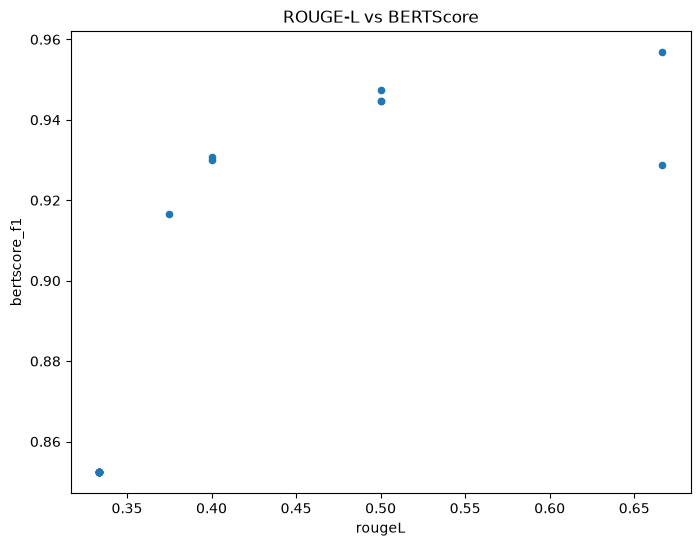

In [28]:
comparison_df.plot(kind="scatter", x="rougeL", y="bertscore_f1", figsize=(8, 6))

plt.title("ROUGE-L vs BERTScore")

plt.show()

In [29]:
evaluation_df.to_csv("../evaluation_results/bertscore_results.csv", index=False)